In [2]:
from py_files.setup import *
setup_notebook()

# `GG-B`-like labour shares

*`1. plot differential`*

In [3]:
# 1. get Leontif inverse values
years = range(1966, 2025)
df_ts = sls.compute_sectoral_ls_timeseries(years, kappa=0.6)

Fetching industry labor shares from NABP36 ...
Processing year 1966...
  1966:  LS_C=0.572  LS_I=0.669  Δ=0.097
Processing year 1967...
  1967:  LS_C=0.573  LS_I=0.684  Δ=0.112
Processing year 1968...
  1968:  LS_C=0.579  LS_I=0.716  Δ=0.136
Processing year 1969...
  1969:  LS_C=0.583  LS_I=0.748  Δ=0.165
Processing year 1970...
  1970:  LS_C=0.586  LS_I=0.770  Δ=0.183
Processing year 1971...
  1971:  LS_C=0.598  LS_I=0.741  Δ=0.144
Processing year 1972...
  1972:  LS_C=0.602  LS_I=0.674  Δ=0.071
Processing year 1973...
  1973:  LS_C=0.592  LS_I=0.700  Δ=0.108
Processing year 1974...
  1974:  LS_C=0.610  LS_I=0.717  Δ=0.107
Processing year 1975...
  1975:  LS_C=0.609  LS_I=0.696  Δ=0.087
Processing year 1976...
  1976:  LS_C=0.607  LS_I=0.731  Δ=0.124
Processing year 1977...
  1977:  LS_C=0.609  LS_I=0.725  Δ=0.117
Processing year 1978...
  1978:  LS_C=0.612  LS_I=0.748  Δ=0.136
Processing year 1979...
  1979:  LS_C=0.612  LS_I=0.811  Δ=0.199
Processing year 1980...
  1980:  LS_C=0.637

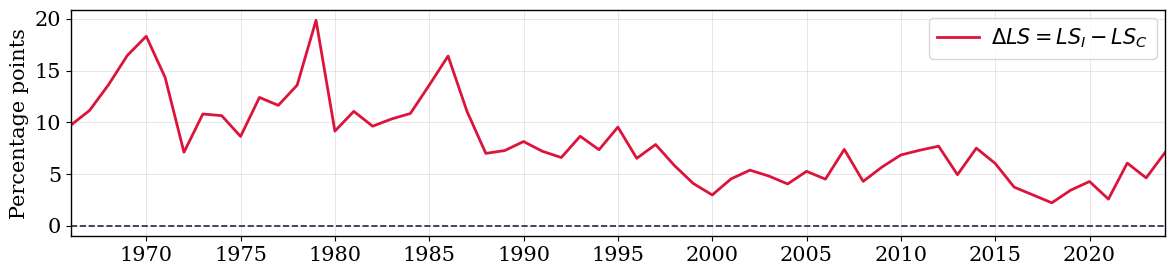

(<Figure size 1200x300 with 1 Axes>, <Axes: ylabel='Percentage points'>)

In [4]:
# 2. plot the difference between sectors
sls.plot_ls_difference(df_ts)

*`2. inspect and sanity`*

In [7]:
# 4. inspect industrylevel
diag = sls.inspect_year(2020)
diag[['direct_ls', 'consolidated_ls', 'w_C', 'w_I']]

Processing year 2020...


,direct_ls,consolidated_ls,w_C,w_I
parent,,,,
F,0.730906,0.730906,0.008403,0.393378
MA,0.742786,0.742786,0.001476,0.239099
G,0.624136,0.624136,0.136655,0.060869
CK,0.640436,0.640436,0.000439,0.034942
P,0.820632,0.820632,0.090542,0.033676
LA,0.189331,0.189331,0.002677,0.030483
MB,0.380567,0.380567,0.001426,0.026631
CF,0.209085,0.209085,0.001064,0.024337
JC,0.675686,0.675686,0.001528,0.024248


In [8]:
# 5. do weights sum to 1?
print(f"w_C sum: {diag['w_C'].sum():.4f}")
print(f"w_I sum: {diag['w_I'].sum():.4f}")

w_C sum: 1.0000
w_I sum: 1.0000


*` 3. create tabel for appendix`*

In [9]:
yr = il.compute_direct_for_year(2024)
out_req = yr['output_requirements'].copy()
use_shares = yr['use_shares'].copy()
X = yr['X'].copy()

# add investment type classification
use_shares['investment_type'] = use_shares.index.map(var_groups.investment_type)
use_shares['parent'] = use_shares.index.map(var_groups.sub_to_parent)
out_req['parent'] = out_req.index.map(var_groups.sub_to_parent)
out_req['investment_type'] = out_req.index.map(var_groups.investment_type)

# split I into tangible and intangible at sub-industry level
tangible_types = ['structures', 'equipment']
intangible_types = ['intellectual_property', 'organizational']

out_req['I_tan']   = out_req['I'] * out_req['investment_type'].isin(tangible_types)
out_req['I_intan'] = out_req['I'] * out_req['investment_type'].isin(intangible_types)

# aggregate to parent
table = out_req.groupby('parent').sum()[['C', 'G', 'I_tan', 'I_intan', 'X']].copy()
table['total'] = table['C'] + table['G'] + table['I_tan'] + table['I_intan'] + table['X']
table['C (%)']     = ((table['C'] + table['G']) / table['total'] * 100).round(1)
table['Tangible (%)']  = (table['I_tan']   / table['total'] * 100).round(1)
table['Intangible (%)']= (table['I_intan'] / table['total'] * 100).round(1)
table['X (%)']     = (table['X'] / table['total'] * 100).round(1)

# size
gdp = il.fetch_gdp_data([2024]).iloc[0]
table['Uses/GDP (%)'] = (table['total'] / gdp * 100).round(1)

# labour shares
df_ls = sls.fetch_industry_labor_shares()
df_ls_yr = df_ls[df_ls['year'] == 2024]
ls_cons = sls.consolidated_labor_shares(yr, df_ls_yr)
ls_cons.index = ls_cons.index.map(var_groups.sub_to_parent)
ls_parent = ls_cons.groupby(ls_cons.index).mean()
table['LS (%)'] = (ls_parent * 100).round(1)

# names and final order
table['Industry'] = table.index.map(var_groups.large_dict)
table = table.set_index('Industry')
table = table[['Uses/GDP (%)', 'C (%)', 'Tangible (%)', 'Intangible (%)', 'X (%)', 'LS (%)']].round(1)
table

Processing year 2024...


,Uses/GDP (%),C (%),Tangible (%),Intangible (%),X (%),LS (%)
Industry,,,,,,
"Agriculture, forestry and fishing",0.9,19.3,0.4,0.0,80.3,53.1
Mining and quarrying,0.3,2.0,3.0,0.0,95.0,27.5
"Manufacture of food products, beverages and tobacco",5.2,24.3,1.1,0.0,74.6,62.3
Textiles and leather products,0.3,14.5,3.2,0.0,82.3,66.2
Wood and paper products and printing,0.4,6.0,2.6,0.0,91.3,72.4
Oil refinery etc.,0.7,38.1,0.0,0.0,61.8,19.1
Manufacture of chemicals,1.5,2.3,5.9,0.0,91.8,31.0
Pharmaceuticals,11.2,0.4,0.0,8.1,91.6,14.7
"Manufacture of plastic, glass and concrete",0.7,7.2,2.5,0.0,90.3,62.2


*`4. plot twice to assess equity`*

In [10]:
# === Baseline ===
years = range(1966, 2024)
df_ts = sls.compute_sectoral_ls_timeseries(years, kappa=0.6)

# === Exclude pharma (21000 / CF) ===
df_ls = sls.fetch_industry_labor_shares()

rows_nopharma = []
for year in years:
    try:
        yr = il.compute_direct_for_year(year)
        df_ls_yr = df_ls[df_ls['year'] == year]
        if df_ls_yr.empty:
            continue
        
        ls_cons = sls.consolidated_labor_shares(yr, df_ls_yr)
        
        # Run sectoral_labor_shares but zero out pharma before weighting
        res = sls.sectoral_labor_shares(yr, ls_cons, kappa=0.6)
        
        # Recompute with pharma zeroed
        w_C = res['weights_C'].copy()
        w_I = res['weights_I'].copy()
        
        # Zero out pharma sub-industry
        pharma_codes = [c for c in w_C.index if c == '21000']
        w_C[pharma_codes] = 0
        w_I[pharma_codes] = 0
        
        # Renormalize
        w_C = w_C / w_C.sum()
        w_I = w_I / w_I.sum()
        
        common = ls_cons.index.intersection(w_C.index)
        LS_C = (w_C[common] * ls_cons[common]).sum()
        LS_I = (w_I[common] * ls_cons[common]).sum()
        
        rows_nopharma.append({
            'year': year,
            'LS_C': LS_C * 100,
            'LS_I': LS_I * 100,
            'LS_I_minus_C': (LS_I - LS_C) * 100,
        })
    except Exception as e:
        print(f"  Error for {year}: {e}")
        continue

df_ts_nopharma = pd.DataFrame(rows_nopharma).set_index('year')

Fetching industry labor shares from NABP36 ...
Processing year 1966...
  1966:  LS_C=0.572  LS_I=0.669  Δ=0.097
Processing year 1967...
  1967:  LS_C=0.573  LS_I=0.684  Δ=0.112
Processing year 1968...
  1968:  LS_C=0.579  LS_I=0.716  Δ=0.136
Processing year 1969...
  1969:  LS_C=0.583  LS_I=0.748  Δ=0.165
Processing year 1970...
  1970:  LS_C=0.586  LS_I=0.770  Δ=0.183
Processing year 1971...
  1971:  LS_C=0.598  LS_I=0.741  Δ=0.144
Processing year 1972...
  1972:  LS_C=0.602  LS_I=0.674  Δ=0.071
Processing year 1973...
  1973:  LS_C=0.592  LS_I=0.700  Δ=0.108
Processing year 1974...
  1974:  LS_C=0.610  LS_I=0.717  Δ=0.107
Processing year 1975...
  1975:  LS_C=0.609  LS_I=0.696  Δ=0.087
Processing year 1976...
  1976:  LS_C=0.607  LS_I=0.731  Δ=0.124
Processing year 1977...
  1977:  LS_C=0.609  LS_I=0.725  Δ=0.117
Processing year 1978...
  1978:  LS_C=0.612  LS_I=0.748  Δ=0.136
Processing year 1979...
  1979:  LS_C=0.612  LS_I=0.811  Δ=0.199
Processing year 1980...
  1980:  LS_C=0.637

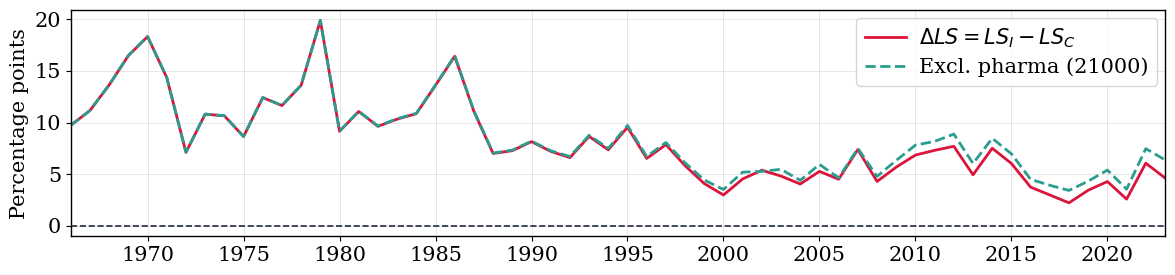

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(12, 3))

ax.plot(df_ts.index, df_ts['LS_I_minus_C'],
        color='crimson', lw=2, label=r'$\Delta LS = LS_I - LS_C$')
ax.plot(df_ts_nopharma.index, df_ts_nopharma['LS_I_minus_C'],
        color='#2A9D8F', lw=2, ls='--', label=r'Excl. pharma (21000)')

ax.axhline(0, color='#1F2A44', linewidth=1.2, ls='--')
ax.set_xlim(df_ts.index.min(), df_ts.index.max())
ax.set_ylabel('Percentage points')
ax.grid(linewidth=0.6, alpha=0.35)
ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=12))
ax.legend(loc='upper right')
plt.tight_layout()
# plt.savefig('0_output/LS_pharma_sensitivity.png', dpi=200)
plt.show()